In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

# Load one image
# image_pikatchu = Image.open("pikatchu/images - 2026-09-04T163734.872.jpeg")
# image_rondoudou = Image.open("rondoudou/OIP (1).webp")
# plt.subplot(1,2,1)
# plt.imshow(image_pikatchu, cmap = "gray")
# plt.subplot(1,2,2)
# plt.imshow(image_rondoudou, cmap = "grey")

def load_images(folder_path, target_size = (64,64)):
    list_pokemon = []

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        image = Image.open(file_path).convert("L")
        if target_size:
            image = image.resize(target_size)
        image = np.array(image, dtype=np.uint8)
        list_pokemon.append(image)

    return list_pokemon


(288, 64, 64)
(235, 64, 64)
(288,)
(235,)
(523, 64, 64)
(523,)


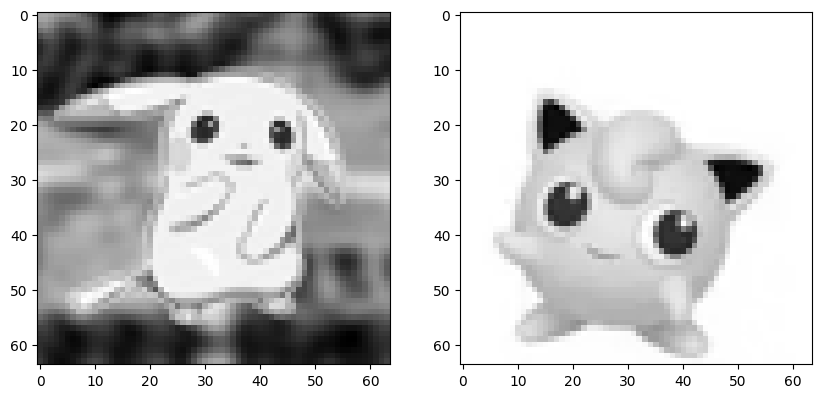

In [10]:
liste_pikatchu = load_images("pikatchu/")
liste_rondoudou = load_images("rondoudou/")

# Convertir en un seul arrayd'array
array_pikatchu = np.asarray(liste_pikatchu)
label_pikatchu = np.zeros(len(liste_pikatchu),dtype=np.int64)
array_rondoudou = np.asarray(liste_rondoudou)
label_rondoudou = np.ones(len(liste_rondoudou),dtype=np.int64)
# array_pikatchu = np.expand_dims(array_pikatchu, axis=-1)
# array_rondoudou = np.expand_dims(array_rondoudou, axis=-1)
print(array_pikatchu.shape)
print(array_rondoudou.shape)
print(label_pikatchu.shape)
print(label_rondoudou.shape)

# fusionner array
X = np.concatenate((array_pikatchu,array_rondoudou))
y = np.concatenate((label_pikatchu,label_rondoudou))

print(X.shape)
print(y.shape)

plt.figure(figsize=(10,12))
plt.subplot(1,2,1)
plt.imshow(array_pikatchu[0,...], cmap = "grey")
plt.subplot(1,2,2)
plt.imshow(array_rondoudou[0,...], cmap = "grey")

In [34]:
# Normalization percentile

def percentile(image:np.array):
    p1 = np.percentile(image, 1)
    p99 = np.percentile(image, 99)

    return (image - p1) / (p99 - p1)

print(array_pikatchu[1].min(),array_pikatchu[1].max())
pikatchu = np.array([percentile(image) for image in array_pikatchu])
print(pikatchu[0].min(),pikatchu[0].max())



0 255
-0.05235602094240838 1.0104712041884816


In [ ]:
# loading dataset 


